# Cross-Sectional Momentum — Signal Validation & Long-Short Backtest

**Thesis.** Stocks that have *out-performed their peers* over the past several months tend to
keep out-performing over the next month; past losers keep lagging. We rank a universe by recent
momentum, go **long the top** / **short the bottom**, and rebalance **monthly**. Two correlation
tools do the heavy lifting:

| Tool | Role | Step |
|------|------|------|
| **Spearman** (rank corr) | Does momentum *rank* predict return *rank*? → the **Information Coefficient (IC)**. Robust to non-linearity and return outliers. | 2 |
| **Pearson** (linear corr) | Risk control — factor overlap, covariance matrix, market-neutrality, position sizing. | 4 |

**Plan** — (1) define universe + the *12&#8209;1* momentum signal, (2) validate it with the
Spearman IC and its t&#8209;stat, (3) confirm the payoff shape with quantile buckets,
(4) use Pearson for factor-overlap & covariance-based sizing / neutrality, (5) backtest the
long-short book with realistic transaction costs and watch the rolling IC for decay.

> Data is the project's Vietnam-equity panel (`load_stocks`, same loader as
> `mvf_lstm_portfolio.ipynb`); the S&P 500 in the thesis text is just the canonical example.


In [52]:
# ── Libraries & path setup (same pattern as mvf_lstm_portfolio.ipynb) ────────
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'backend'))   # numba disk-cache stores module paths as `app.*`

np.random.seed(42)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print('pandas', pd.__version__)

pandas 2.2.2


In [53]:
# ── Load OHLCV via the project data loader ───────────────────────────────────
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'
df = load_stocks()

close  = df.close.copy()
volume = df.volume.copy()
print(f'Panel : {close.shape[1]} symbols × {len(close)} bars  '
      f'|  {close.index[0].date()} → {close.index[-1].date()}')

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2499, 985)  |  2016-07-11 → 2026-07-08
Panel : 197 symbols × 2499 bars  |  2016-07-11 → 2026-07-08


## Step 1 — Universe & the *12&#8209;1* momentum signal

**Universe.** Cross-sectional momentum needs *breadth* (enough names to fill each quantile), so we
keep the most liquid `N_UNIV` names — ranked by **median daily traded value** (`close × volume`) —
dropping the index and thinly-traded names. Names must have a reasonably complete history.

**Signal.** The textbook momentum factor is the **12&#8209;1 return**: cumulative return from
12 months ago up to 1 month ago. Skipping the most recent month sidesteps the well-known
short-term *reversal* effect. At month *t*:

$$\text{MOM}_t \;=\; \frac{P_{t-1}}{P_{t-12}} - 1$$

That single number is each stock's factor score. The **forward return** we try to predict is the
*next* month's return, $P_{t+1}/P_t - 1$ — realized strictly after the score is known (no look-ahead).


In [54]:
# ── Configuration ────────────────────────────────────────────────────────────
MOM_LOOKBACK = 6     # months in the momentum window
MOM_SKIP     = 0      # skip the most recent month (avoid short-term reversal) -> "12-1"
N_UNIV       = 120     # universe size (most liquid names)
N_Q          = 5       # quantiles (quintiles) for the sort
MIN_NAMES    = 40      # minimum valid stocks required to score a month
COST_BPS     = 10      # one-way transaction cost, basis points (10 bps = 0.10%)
ANN          = 12      # periods per year (monthly rebalancing)

INDEX_LIKE = {'VNINDEX', 'VN30', 'HNXINDEX', 'UPINDEX'}

# liquidity ranking, excluding index-like tickers
dollar_vol = (close * volume).median()
dollar_vol = dollar_vol.drop(labels=[c for c in INDEX_LIKE if c in dollar_vol.index],
                             errors='ignore')
# require a mostly-complete history so early months have breadth
enough_hist = close.columns[close.notna().mean() >= 0.80]
dollar_vol  = dollar_vol[dollar_vol.index.isin(enough_hist)]

UNIVERSE = list(dollar_vol.sort_values(ascending=False).head(N_UNIV).index)
px = close[UNIVERSE].copy()

# month-end panels
m_close = px.resample('ME').last()
m_ret   = m_close.pct_change()

print(f'Universe : {len(UNIVERSE)} names  |  monthly panel {m_close.shape}  '
      f'({m_close.index[0].date()} → {m_close.index[-1].date()})')
print('Top-10 by liquidity:', UNIVERSE[:10])

Universe : 120 names  |  monthly panel (121, 120)  (2016-07-31 → 2026-07-31)
Top-10 by liquidity: ['STB', 'HPG', 'VPB', 'MSB', 'SSI', 'VHM', 'NVL', 'VNM', 'DXS', 'PVS']


In [55]:
# ── Momentum score (12-1) and the forward return it must predict ─────────────
# MOM_t : known at month t (uses prices up to t-1)  ->  P[t-SKIP] / P[t-LOOKBACK] - 1
mom = m_close.shift(MOM_SKIP) / m_close.shift(MOM_LOOKBACK) - 1.0
# forward return : realized over month t -> t+1 (strictly after the score)
fwd = m_ret.shift(-1)

# breadth diagnostic: how many months have enough scored names to trade
scored = (mom.notna() & fwd.notna())
n_names = scored.sum(axis=1)
tradable = n_names[n_names >= MIN_NAMES]
print(f'{len(tradable)} tradable months (>= {MIN_NAMES} names)  |  '
      f'{tradable.index[0].date()} → {tradable.index[-1].date()}')
print(f'Median names / month: {int(n_names.loc[tradable.index].median())}')
mom.tail(3).iloc[:, :6]

114 tradable months (>= 40 names)  |  2017-01-31 → 2026-06-30
Median names / month: 120


symbol,STB,HPG,VPB,MSB,SSI,VHM
date,,,,,,
2026-05-31,0.3992,0.0127,-0.0735,0.1635,-0.0797,0.5160
2026-06-30,0.2724,-0.0112,-0.0576,0.3065,-0.1157,0.2242
2026-07-31,0.1254,-0.0302,-0.0089,0.2903,-0.1268,0.4151


## Step 2 — Validate the signal with the Spearman IC

Before risking capital we need evidence the signal *predicts* returns. Each month we take the
momentum scores across all stocks, rank them, rank next month's actual returns, and compute the
**Spearman correlation** between the two rankings — the monthly **Information Coefficient (IC)**.

We use **Spearman, not Pearson**, on purpose: we only care whether *higher momentum rank → higher
return rank*, not whether the relationship is linear, and a few extreme-return names shouldn't
dominate the verdict.

We then judge the series of monthly ICs:

- **Mean IC** — economic strength (≈ 0.03–0.06 is a real, tradable equity factor).
- **t&#8209;stat** = mean&nbsp;/&nbsp;(std&nbsp;/&nbsp;√N) — is it statistically distinguishable from zero? (> 2 ≈ significant.)
- **IR** = mean&nbsp;/&nbsp;std of IC — stability of the edge.
- **Hit rate** — share of months with positive IC.


In [56]:
# ── Monthly cross-sectional IC ───────────────────────────────────────────────
def cross_sectional_ic(scores, forwards, method='spearman', min_names=MIN_NAMES):
    """One IC per month: correlation of scores-vs-forward-returns ACROSS stocks."""
    out = {}
    for dt in scores.index:
        s, f = scores.loc[dt], forwards.loc[dt]
        m = s.notna() & f.notna()
        if m.sum() < min_names:
            continue
        if method == 'spearman':
            out[dt] = stats.spearmanr(s[m], f[m]).correlation
        else:                                    # pearson
            out[dt] = np.corrcoef(s[m], f[m])[0, 1]
    return pd.Series(out).sort_index()

ic = cross_sectional_ic(mom, fwd, 'spearman')

mean_ic = ic.mean()
std_ic  = ic.std()
n       = ic.notna().sum()
t_stat  = mean_ic / (std_ic / np.sqrt(n))
ir      = mean_ic / std_ic
hit     = (ic > 0).mean()

print(f'Spearman IC over {n} months')
print(f'  mean IC   : {mean_ic:+.4f}')
print(f'  std  IC   : {std_ic:.4f}')
print(f'  t-stat    : {t_stat:+.2f}   {"(significant)" if abs(t_stat) > 2 else "(weak)"}')
print(f'  IR (mean/std): {ir:+.3f}')
print(f'  hit rate  : {hit:.1%} of months IC > 0')

Spearman IC over 114 months
  mean IC   : +0.0309
  std  IC   : 0.2387
  t-stat    : +1.38   (weak)
  IR (mean/std): +0.130
  hit rate  : 60.5% of months IC > 0


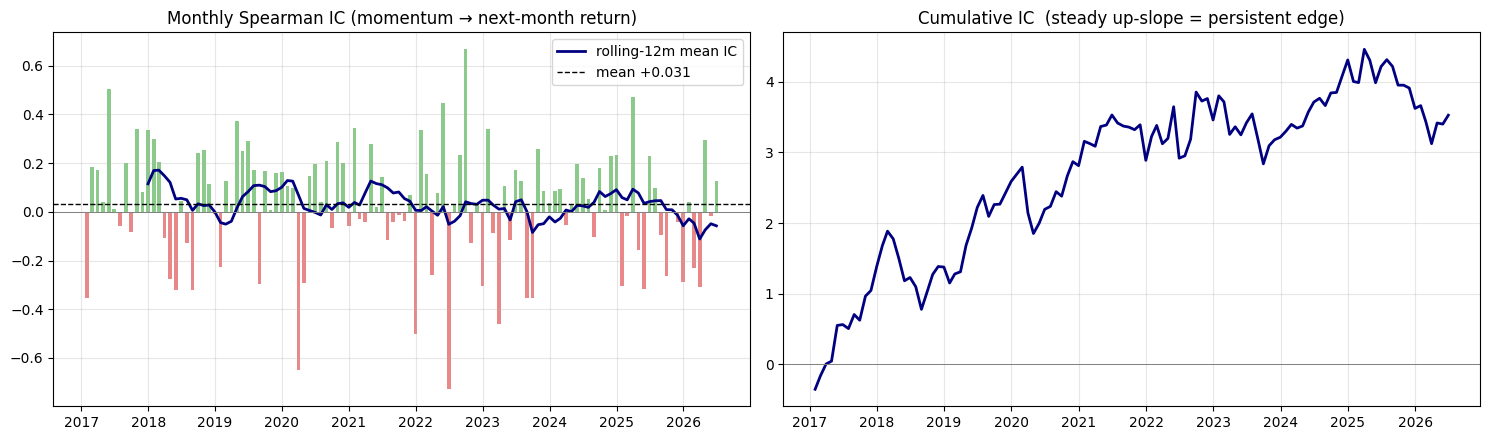

In [57]:
# ── Visualize the IC: monthly, rolling-12m mean, and cumulative ──────────────
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

ax[0].bar(ic.index, ic.values, width=20,
          color=np.where(ic.values > 0, '#2ca02c', '#d62728'), alpha=0.55)
ax[0].plot(ic.index, ic.rolling(12).mean(), color='navy', lw=2, label='rolling-12m mean IC')
ax[0].axhline(mean_ic, color='k', ls='--', lw=1, label=f'mean {mean_ic:+.3f}')
ax[0].axhline(0, color='grey', lw=0.7)
ax[0].set_title('Monthly Spearman IC (momentum → next-month return)')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ic.index, ic.cumsum(), color='navy', lw=2)
ax[1].set_title('Cumulative IC  (steady up-slope = persistent edge)')
ax[1].axhline(0, color='grey', lw=0.7); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 3 — Confirm the payoff shape with quantile analysis

Complementing the IC, each month we sort stocks into `N_Q` quantiles by momentum and track each
bucket's **average forward return**. A healthy factor rises roughly **monotonically** from Q1
(lowest momentum) to Q5 (highest). This visual confirms what the IC implies and reveals the
expected **long–short spread** — the return of the Q5 long book minus the Q1 short book.


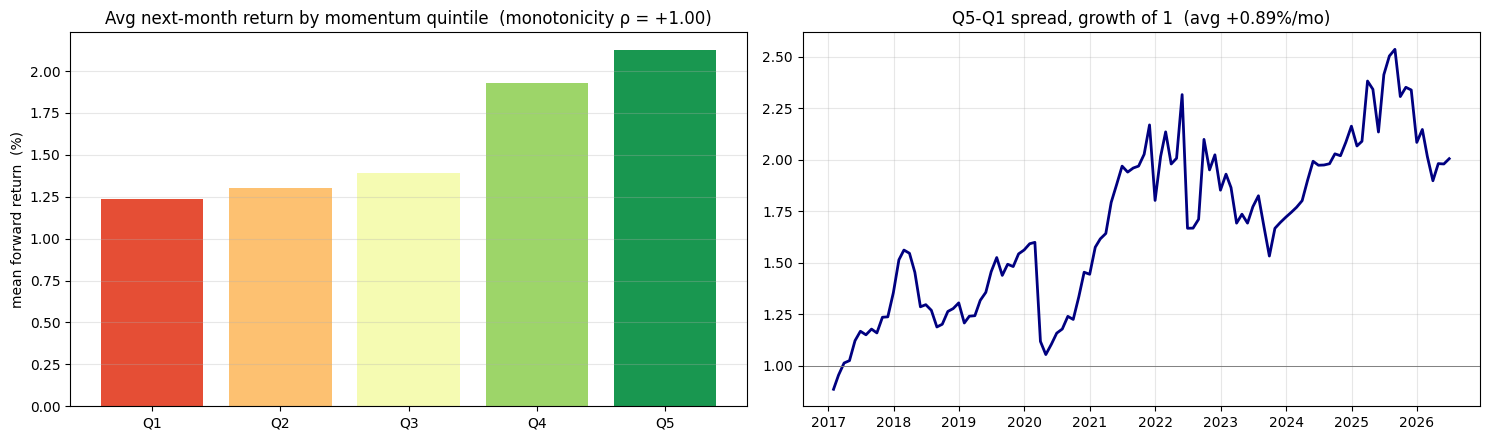

Q5 (winners) avg fwd: +2.12%/mo   Q1 (losers) avg fwd: +1.24%/mo   spread: +0.89%/mo


In [58]:
# ── Quantile forward-return profile ──────────────────────────────────────────
def quantile_forward(scores, forwards, nq=N_Q, min_names=MIN_NAMES):
    rows = {}
    for dt in scores.index:
        s, f = scores.loc[dt], forwards.loc[dt]
        m = s.notna() & f.notna()
        if m.sum() < min_names:
            continue
        # rank(first) breaks ties so qcut always gets nq clean bins
        q = pd.qcut(s[m].rank(method='first'), nq, labels=False)
        rows[dt] = f[m].groupby(q).mean()
    return pd.DataFrame(rows).T.sort_index()

qf = quantile_forward(mom, fwd)               # months × quantile
avg_q = qf.mean()                             # mean forward return per quantile
ls_spread = qf[N_Q - 1] - qf[0]               # Q5 - Q1 each month

# monotonicity: Spearman between quantile index and its mean forward return
mono = stats.spearmanr(np.arange(N_Q), avg_q.values).correlation

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, N_Q))
ax[0].bar([f'Q{i+1}' for i in range(N_Q)], avg_q.values * 100, color=colors)
ax[0].set_title(f'Avg next-month return by momentum quintile  (monotonicity ρ = {mono:+.2f})')
ax[0].set_ylabel('mean forward return  (%)'); ax[0].grid(alpha=0.3, axis='y')

ls_eq = (1 + ls_spread.dropna()).cumprod()
ax[1].plot(ls_eq.index, ls_eq.values, color='navy', lw=2)
ax[1].axhline(1, color='grey', lw=0.7)
ax[1].set_title(f'Q5-Q1 spread, growth of 1  (avg {ls_spread.mean()*100:+.2f}%/mo)')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Q5 (winners) avg fwd: {avg_q.iloc[-1]*100:+.2f}%/mo   '
      f'Q1 (losers) avg fwd: {avg_q.iloc[0]*100:+.2f}%/mo   '
      f'spread: {(avg_q.iloc[-1]-avg_q.iloc[0])*100:+.2f}%/mo')

## Step 4 — Pearson for risk control

Now **Pearson** takes over. Two jobs:

**(a) Factor overlap.** If we combine momentum with a second factor, we want to know how much they
already overlap. We compute the cross-sectional Pearson correlation between the two scores each
month. A strong negative correlation means the signals partly offset — a candidate for
orthogonalization or deliberate weighting so we don't make an unintended concentrated bet.
Here the second factor is **short-term (1-month) reversal**, `-P_t/P_{t-1}` — a natural momentum
antagonist that stands in for the *value* factor (this panel has no fundamentals).

**(b) Covariance-based sizing & neutrality.** The covariance matrix is fundamentally Pearson-based.
For the most recent formation we build the long-short book's covariance from trailing daily
returns, check we're not piling into mutually-correlated names, size positions **inverse-vol**
(a simple risk-parity step), and confirm the book is roughly **market-neutral** (net β ≈ 0).


In [59]:
# ── (a) Cross-sectional Pearson: momentum vs a second (reversal) factor ──────
rev = -m_ret        # short-term reversal factor (recent losers score high); value-factor stand-in

def cross_sectional_corr(a, b, min_names=MIN_NAMES):
    out = {}
    for dt in a.index:
        x, y = a.loc[dt], b.loc[dt]
        m = x.notna() & y.notna()
        if m.sum() >= min_names:
            out[dt] = np.corrcoef(x[m], y[m])[0, 1]
    return pd.Series(out).sort_index()

factor_corr = cross_sectional_corr(mom, rev)
print(f'Avg cross-sectional Pearson(momentum, reversal): {factor_corr.mean():+.3f}  '
      f'(negative ⇒ the two factors partly offset — orthogonalize before combining)')

Avg cross-sectional Pearson(momentum, reversal): -0.393  (negative ⇒ the two factors partly offset — orthogonalize before combining)


Latest formation @ 2026-07-31  |  24 longs / 24 shorts
  gross exposure : 2.00   net exposure : +0.00
  Σ condition #  : 82   avg pairwise corr : +0.28
  portfolio net β vs VNINDEX : +0.07  (≈ market-neutral)


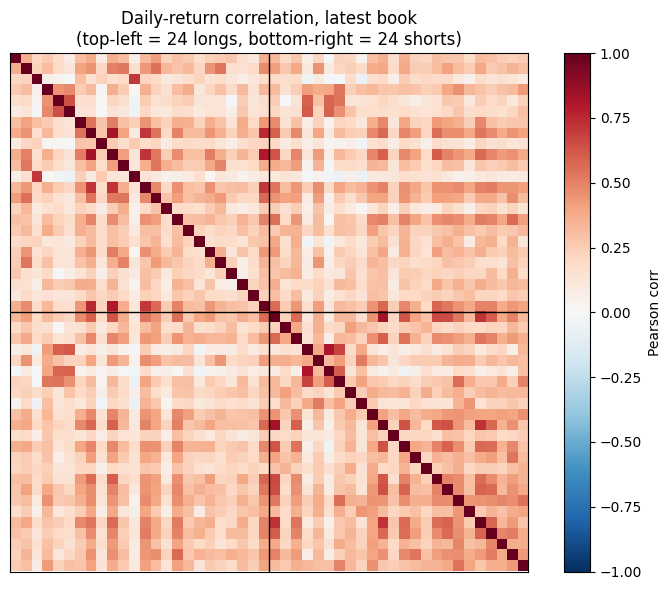

In [60]:
# ── (b) Covariance, correlation heatmap & market-neutrality of the latest book ─
from sklearn.covariance import LedoitWolf

daily_ret  = px.pct_change()
bench_dret = close[BENCHMARK].pct_change()

# most recent month with a full score
last_dt = mom.index[mom.notna().sum(axis=1) >= MIN_NAMES][-1]
s_last  = mom.loc[last_dt].dropna()
q_last  = pd.qcut(s_last.rank(method='first'), N_Q, labels=False)
longs   = list(q_last[q_last == N_Q - 1].index)
shorts  = list(q_last[q_last == 0].index)
book    = longs + shorts

# trailing ~1y of daily returns up to the formation date
win = daily_ret.loc[:last_dt, book].dropna(how='all').tail(252).dropna(axis=1)
book = list(win.columns)
longs  = [s for s in longs  if s in book]
shorts = [s for s in shorts if s in book]

Sigma = pd.DataFrame(LedoitWolf().fit(win.values).covariance_, index=book, columns=book)
Corr  = win.corr()

# inverse-vol (risk-parity) sizing: long book sums +1, short book sums -1  -> dollar-neutral
vol = np.sqrt(np.diag(Sigma))
vol = pd.Series(vol, index=book)
w = pd.Series(0.0, index=book)
w[longs]  =  (1 / vol[longs])  / (1 / vol[longs]).sum()
w[shorts] = -(1 / vol[shorts]) / (1 / vol[shorts]).sum()

# market beta of each name over the same window -> portfolio net beta
mkt = bench_dret.reindex(win.index)
var_mkt = mkt.var()
beta = win.apply(lambda col: np.cov(col, mkt)[0, 1] / var_mkt)
net_beta = float((w * beta).sum())

print(f'Latest formation @ {last_dt.date()}  |  {len(longs)} longs / {len(shorts)} shorts')
print(f'  gross exposure : {w.abs().sum():.2f}   net exposure : {w.sum():+.2f}')
print(f'  Σ condition #  : {np.linalg.cond(Sigma.values):.0f}   '
      f'avg pairwise corr : {Corr.values[np.triu_indices_from(Corr.values, 1)].mean():+.2f}')
print(f'  portfolio net β vs {BENCHMARK} : {net_beta:+.2f}  '
      f'{"(≈ market-neutral)" if abs(net_beta) < 0.2 else "(has market tilt)"}')

plt.figure(figsize=(7.5, 6))
order = longs + shorts
plt.imshow(Corr.loc[order, order].values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Pearson corr')
plt.axhline(len(longs) - 0.5, color='k', lw=1); plt.axvline(len(longs) - 0.5, color='k', lw=1)
plt.title(f'Daily-return correlation, latest book\n(top-left = {len(longs)} longs, '
          f'bottom-right = {len(shorts)} shorts)')
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

## Step 5 — Backtest with realistic frictions

We simulate history: each month rank by momentum, form the long-short book, hold one month,
rebalance. Momentum turns over a lot as rankings shift, so we **subtract transaction costs**
proportional to turnover. We report **annualized return, volatility, Sharpe, and max drawdown**,
and compare weighting schemes and passive baselines.

- **L/S equal-weight** — Q5 long / Q1 short, dollar-neutral (gross 2, net 0).
- **L/S inverse-vol** — same books, Pearson-covariance-driven risk-parity sizing (Step 4).
- **Long-only Q5** — winners book only (long-only accounts).
- **VNINDEX** — the market benchmark. Does the active strategy earn its costs?


In [61]:
# ── Build monthly weight matrices ────────────────────────────────────────────
# trailing daily vol sampled at each month-end (for inverse-vol sizing)
vol_daily = daily_ret.rolling(60).std().reindex(m_close.index, method='ffill')

def build_weights(scores, nq=N_Q, long_short=True, weighting='equal', min_names=MIN_NAMES):
    W = pd.DataFrame(0.0, index=scores.index, columns=scores.columns)
    for dt in scores.index:
        s = scores.loc[dt]; m = s.notna()
        if m.sum() < min_names:
            continue
        q = pd.qcut(s[m].rank(method='first'), nq, labels=False)
        longs  = q[q == nq - 1].index
        shorts = q[q == 0].index
        def _w(names, sign):
            if weighting == 'invvol':
                iv = 1.0 / vol_daily.loc[dt, names].replace(0, np.nan)
                iv = iv.fillna(iv.median())
                return sign * iv / iv.sum()
            return pd.Series(sign / len(names), index=names)
        W.loc[dt, longs] = _w(longs, 1.0).values
        if long_short:
            W.loc[dt, shorts] = _w(shorts, -1.0).values
    return W

W_ls_eq  = build_weights(mom, long_short=True,  weighting='equal')
W_ls_iv  = build_weights(mom, long_short=True,  weighting='invvol')
W_long   = build_weights(mom, long_short=False, weighting='equal')

def backtest(W, forwards, cost_bps=COST_BPS):
    active = W.abs().sum(axis=1) > 0
    W = W.loc[active]
    gross = (W * forwards.reindex(W.index)).sum(axis=1)          # return realized month t->t+1
    turnover = (W - W.shift(1)).abs().sum(axis=1)                # 1st rebalance = full entry
    cost = turnover * cost_bps / 1e4
    net = (gross - cost).dropna()
    return net, gross.dropna(), turnover.dropna()

net_ls_eq, gr_ls_eq, to_ls_eq = backtest(W_ls_eq, fwd)
net_ls_iv, _, to_ls_iv        = backtest(W_ls_iv, fwd)
net_long,  _, _               = backtest(W_long, fwd)

# benchmark monthly return, aligned to the L/S sample
bench_m = m_close.index  # month-end grid
bench_ret_m = close[BENCHMARK].resample('ME').last().pct_change().reindex(net_ls_eq.index)

print(f'Avg monthly one-way turnover (L/S equal): {to_ls_eq.mean():.2f}  '
      f'⇒ annual cost ≈ {to_ls_eq.mean()*ANN*COST_BPS/1e4*100:.1f}% at {COST_BPS}bps')

Avg monthly one-way turnover (L/S equal): 1.21  ⇒ annual cost ≈ 1.5% at 10bps


Out-of-sample-style backtest (net of costs):


,ann_ret,ann_vol,sharpe,max_dd
L/S equal-weight,0.0600,0.2500,0.2390,-0.3530
L/S inverse-vol,0.0680,0.2510,0.2710,-0.3710
Long-only Q5,0.2250,0.2880,0.7800,-0.4260
VNINDEX,0.1130,0.2100,0.5370,-0.4360


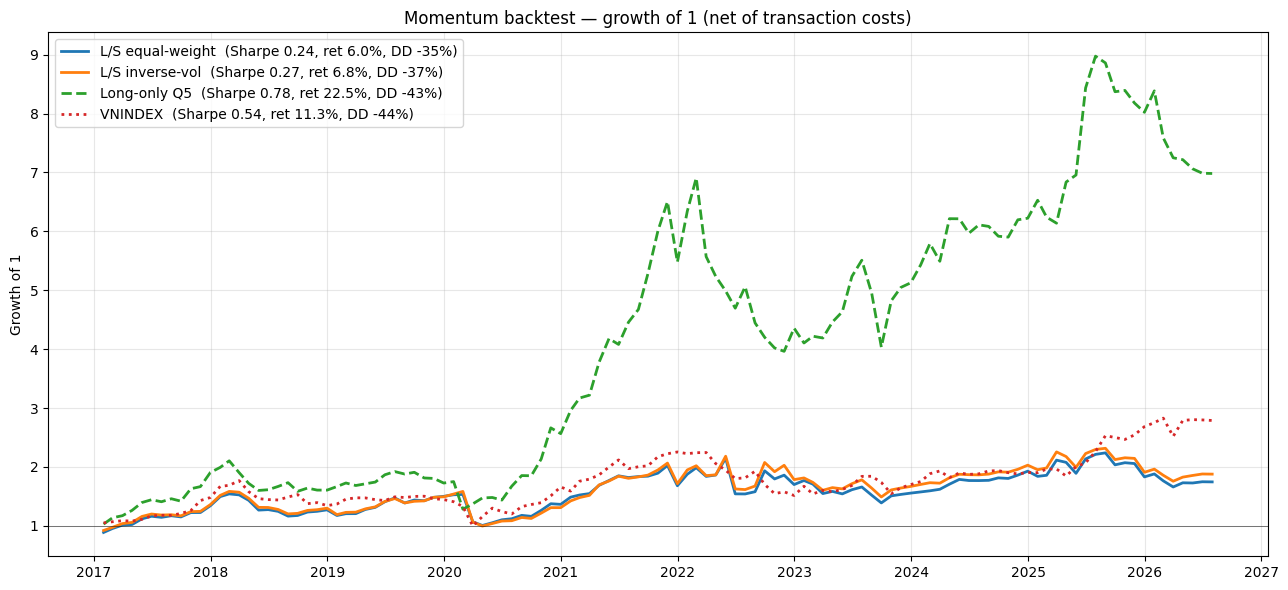

In [62]:
# ── Performance metrics & equity curves ──────────────────────────────────────
def perf(r):
    r = r.dropna()
    eq = (1 + r).cumprod()
    ann_ret = (1 + r).prod() ** (ANN / len(r)) - 1
    ann_vol = r.std() * np.sqrt(ANN)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    dd = (eq / eq.cummax() - 1).min()
    return dict(ann_ret=ann_ret, ann_vol=ann_vol, sharpe=sharpe, max_dd=dd, eq=eq)

strats = {
    'L/S equal-weight': net_ls_eq,
    'L/S inverse-vol' : net_ls_iv,
    'Long-only Q5'    : net_long,
    BENCHMARK         : bench_ret_m,
}
res = {k: perf(v) for k, v in strats.items()}

summary = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'eq'}
                        for k, v in res.items()}).T
summary = summary[['ann_ret', 'ann_vol', 'sharpe', 'max_dd']]
print('Out-of-sample-style backtest (net of costs):')
display(summary.round(3))

plt.figure(figsize=(13, 6))
styles = {'L/S equal-weight': '-', 'L/S inverse-vol': '-',
          'Long-only Q5': '--', BENCHMARK: ':'}
for name, r in res.items():
    plt.plot(r['eq'].index, r['eq'].values, styles.get(name, '-'), lw=2,
             label=f"{name}  (Sharpe {r['sharpe']:.2f}, ret {r['ann_ret']:.1%}, DD {r['max_dd']:.0%})")
plt.axhline(1, color='k', lw=0.7, alpha=0.5)
plt.title('Momentum backtest — growth of 1 (net of transaction costs)')
plt.ylabel('Growth of 1'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

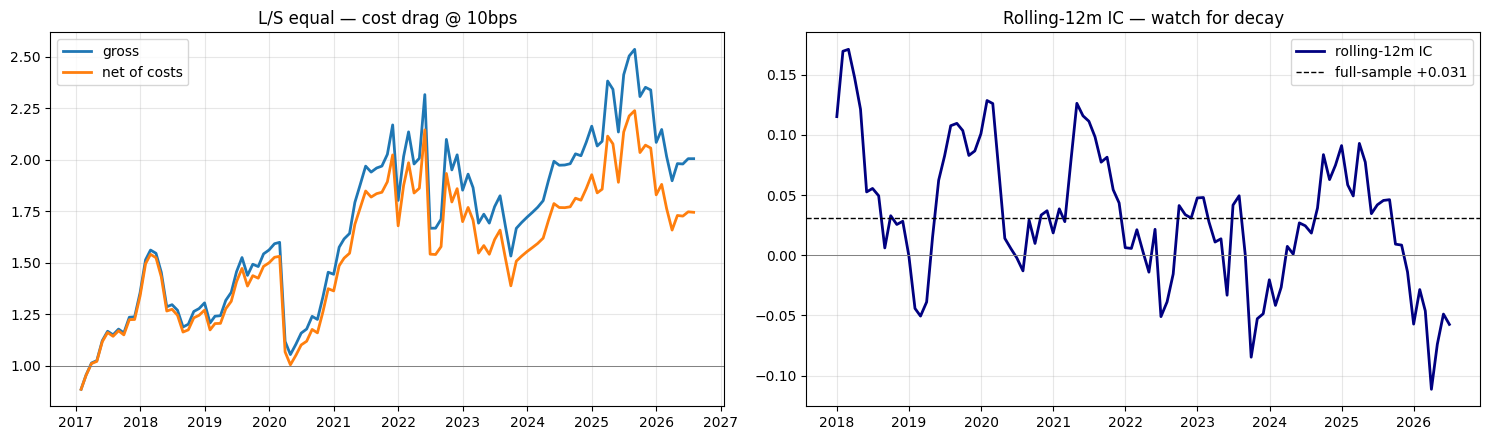

Full-sample mean IC +0.0309  vs  last-12m mean IC -0.0574  (DECAYING — investigate)


In [63]:
# ── Cost drag & rolling-IC decay monitor ─────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

# gross vs net: how much do frictions eat?
ax[0].plot(gr_ls_eq.index, (1 + gr_ls_eq).cumprod(), lw=2, label='gross')
ax[0].plot(net_ls_eq.index, (1 + net_ls_eq).cumprod(), lw=2, label='net of costs')
ax[0].axhline(1, color='grey', lw=0.7)
ax[0].set_title(f'L/S equal — cost drag @ {COST_BPS}bps'); ax[0].legend(); ax[0].grid(alpha=0.3)

# rolling IC: is the signal decaying?
ax[1].plot(ic.index, ic.rolling(12).mean(), color='navy', lw=2, label='rolling-12m IC')
ax[1].axhline(mean_ic, color='k', ls='--', lw=1, label=f'full-sample {mean_ic:+.3f}')
ax[1].axhline(0, color='grey', lw=0.7)
ax[1].set_title('Rolling-12m IC — watch for decay'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

recent = ic.tail(12).mean()
print(f'Full-sample mean IC {mean_ic:+.4f}  vs  last-12m mean IC {recent:+.4f}  '
      f'({"holding up" if recent > mean_ic*0.5 else "DECAYING — investigate"})')

## Step 6 — Parameter sweep: is *any* momentum variant significant?

The default 12&#8209;1 signal was weak. Before discarding momentum, we sweep the two levers that
define it — the **lookback** (3/6/9/12 months) and the **skip** (0 or 1 month) — across three
**universe sizes** (60 / 120 / all liquid names). For each combination we recompute the Spearman
IC t&#8209;stat and the net long-short Sharpe, so we can see whether the thesis fails for momentum
*as a concept* here, or merely for the specific 12&#8209;1 parameterization.

In [64]:
# ── Sweep lookback × skip × universe; score by IC t-stat and net L/S Sharpe ──
def ls_net(mom_s, fwd_s, cols):
    W = pd.DataFrame(0.0, index=mom_s.index, columns=cols)
    for dt in mom_s.index:
        s = mom_s.loc[dt]; m = s.notna()
        if m.sum() < MIN_NAMES:
            continue
        q = pd.qcut(s[m].rank(method='first'), N_Q, labels=False)
        L = q[q == N_Q - 1].index; S = q[q == 0].index
        W.loc[dt, L] = 1.0 / len(L); W.loc[dt, S] = -1.0 / len(S)
    W = W.loc[W.abs().sum(axis=1) > 0]
    gross = (W * fwd_s.reindex(W.index)).sum(axis=1)
    net = (gross - (W - W.shift(1)).abs().sum(axis=1) * COST_BPS / 1e4).dropna()
    if len(net) < 12:
        return np.nan
    ar = (1 + net).prod() ** (ANN / len(net)) - 1
    av = net.std() * np.sqrt(ANN)
    return ar / av if av > 0 else np.nan

liq_all = list(dollar_vol.sort_values(ascending=False).index)     # from Step 1
rows = []
for lb, sk, nu in itertools.product([3, 6, 9, 12], [0, 1], [60, 120, len(liq_all)]):
    if sk >= lb:
        continue
    uni = liq_all[:nu]
    mc  = close[uni].resample('ME').last()
    m_  = mc.shift(sk) / mc.shift(lb) - 1.0                        # momentum for this variant
    fw_ = mc.pct_change().shift(-1)
    icv = cross_sectional_ic(m_, fw_, 'spearman')
    k = icv.notna().sum()
    if k < 12:
        continue
    t = icv.mean() / (icv.std() / np.sqrt(k))
    rows.append({'lookback': lb, 'skip': sk, 'univ': nu, 'n_mo': k,
                 'mean_IC': icv.mean(), 't_stat': t, 'hit': (icv > 0).mean(),
                 'IC_last12': icv.tail(12).mean(), 'LS_sharpe': ls_net(m_, fw_, uni)})

sweep = pd.DataFrame(rows)
sweep_sorted = sweep.reindex(sweep.t_stat.abs().sort_values(ascending=False).index)
print('Sweep — sorted by |t-stat| (none exceed the |t| > 2 significance bar):')
display(sweep_sorted.round(3).reset_index(drop=True))

sig = sweep[sweep.t_stat.abs() > 2]
print(f'\nSignificant variants (|t| > 2): {"NONE" if sig.empty else len(sig)}')
print(f'Best |t|: {sweep.t_stat.abs().max():.2f}  '
      f'({sweep.loc[sweep.t_stat.abs().idxmax(), ["lookback","skip","univ"]].to_dict()})')

Sweep — sorted by |t-stat| (none exceed the |t| > 2 significance bar):


,lookback,skip,univ,n_mo,mean_IC,t_stat,hit,IC_last12,LS_sharpe
0,6,0,120,114,0.0310,1.3840,0.6050,-0.0570,0.2390
1,3,0,60,117,0.0300,1.3310,0.5980,-0.0600,0.2860
2,6,0,60,114,0.0340,1.3220,0.5700,-0.0650,0.1780
3,3,0,120,117,0.0230,1.1710,0.5640,-0.0560,0.2260
4,6,0,195,114,0.0210,1.0670,0.5960,-0.0460,0.2380
5,9,0,60,111,0.0260,1.0160,0.5680,-0.0700,0.1050
6,3,1,120,117,0.0160,0.8520,0.5730,-0.0770,0.0810
7,6,1,120,114,0.0190,0.8510,0.5880,-0.0790,0.0810
8,9,1,60,111,0.0200,0.7870,0.5590,-0.1020,-0.0460
9,9,0,120,111,0.0170,0.7820,0.5860,-0.0740,0.0960



Significant variants (|t| > 2): NONE
Best |t|: 1.38  ({'lookback': 6.0, 'skip': 0.0, 'univ': 120.0})


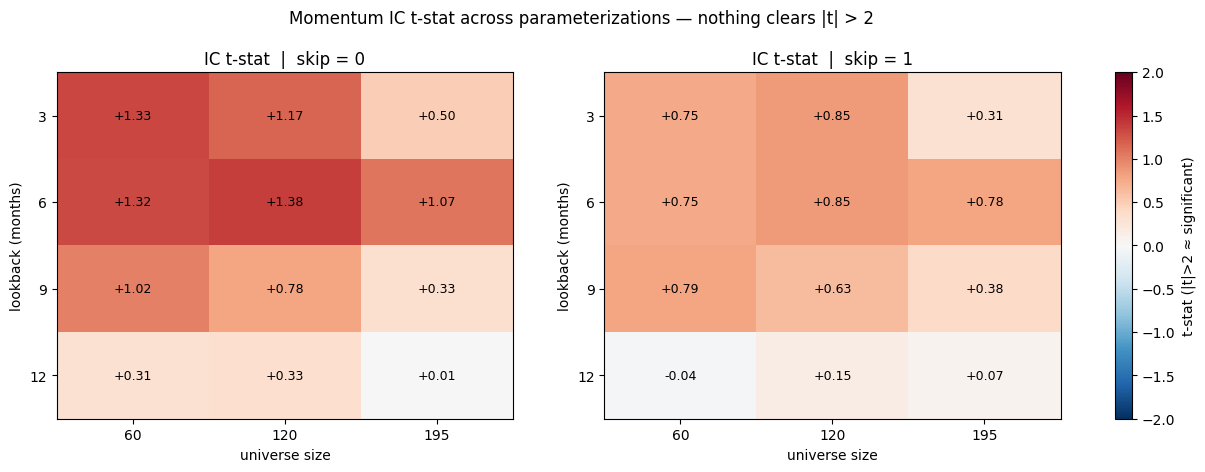

Strongest variant: 6-0 on top-120  → mean IC +0.031, t +1.38, net L/S Sharpe +0.24
skip=0 columns dominate skip=1 ⇒ this market shows momentum *continuation* into the most recent month, not the US-style short-term reversal the skip is meant to avoid.


In [65]:
# ── Heatmaps: IC t-stat by lookback × universe, split by skip ────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for j, sk in enumerate([0, 1]):
    piv = (sweep[sweep.skip == sk]
           .pivot(index='lookback', columns='univ', values='t_stat'))
    im = ax[j].imshow(piv.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
    ax[j].set_xticks(range(len(piv.columns))); ax[j].set_xticklabels(piv.columns)
    ax[j].set_yticks(range(len(piv.index)));   ax[j].set_yticklabels(piv.index)
    ax[j].set_xlabel('universe size'); ax[j].set_ylabel('lookback (months)')
    ax[j].set_title(f'IC t-stat  |  skip = {sk}')
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            v = piv.values[r, c]
            if np.isfinite(v):
                ax[j].text(c, r, f'{v:+.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, label='t-stat (|t|>2 ≈ significant)', fraction=0.025)
plt.suptitle('Momentum IC t-stat across parameterizations — nothing clears |t| > 2', y=1.02)
plt.show()

best = sweep_sorted.iloc[0]
print(f"Strongest variant: {int(best.lookback)}-{int(best.skip)} on top-{int(best.univ)}  "
      f"→ mean IC {best.mean_IC:+.3f}, t {best.t_stat:+.2f}, net L/S Sharpe {best.LS_sharpe:+.2f}")
print("skip=0 columns dominate skip=1 ⇒ this market shows momentum *continuation* into the "
      "most recent month, not the US-style short-term reversal the skip is meant to avoid.")

## Step 7 — The current tradable book (long-only)

Putting the winning variant to work: rank the top-120 liquid universe by the **6&#8209;month,
`skip = 0`** signal as of the latest formation date and hold the **top quintile long only** —
no shorts. Size the names **inverse-vol** (the Step&#8209;4 risk-parity step) and stay **fully
invested** (weights sum to 1). Being long-only, the book carries market beta ≈ 1, so the honest
benchmark is **buying and holding VNINDEX** (Step 8), not a market-neutral book.

In [67]:
# ── Current LONG-ONLY book from the winning variant (6-month, skip=0) ────────
LB_WIN  = 6
mom_win = m_close / m_close.shift(LB_WIN) - 1.0                 # 6-month momentum, no skip
form_dt = mom_win.dropna(how='all').index[-1]
s_now   = mom_win.loc[form_dt].dropna()
q_now   = pd.qcut(s_now.rank(method='first'), N_Q, labels=False)
longs   = s_now[q_now == N_Q - 1].sort_values(ascending=False)  # top-quintile winners only

# inverse-vol (risk-parity) sizing; fully invested -> weights sum to 1 (long-only, net +1)
iv = (1.0 / vol_daily.loc[form_dt, longs.index].replace(0, np.nan))
iv = iv.fillna(iv.median())
book = pd.DataFrame({'6mo_ret': longs, 'weight': iv / iv.sum()})

print(f'Current LONG-ONLY book @ {form_dt.date()}  |  {len(longs)} names  '
      f'|  gross {book.weight.sum():.2f}  net {book.weight.sum():+.2f}')
print('\nHOLD (top momentum): ' + ', '.join(longs.index))
display(book.round(3))

Current LONG-ONLY book @ 2026-07-31  |  24 names  |  gross 1.00  net +1.00

HOLD (top momentum): PET, VIC, VHM, ABB, MSB, LPB, HCM, SSB, GEX, VPI, GMD, NAB, DVM, STB, BSR, ACB, VCG, POW, VJC, PVD, HNG, SHS, MBS, VND


,6mo_ret,weight
symbol,,
PET,0.6630,0.0330
VIC,0.5710,0.0270
VHM,0.4150,0.0230
ABB,0.3670,0.0730
MSB,0.2900,0.0470
LPB,0.2750,0.0320
HCM,0.2180,0.0410
SSB,0.1530,0.0640
GEX,0.1420,0.0280


## Step 8 — Regime-gate the long-only book (`market_regime.ipynb` labels)

A long-only momentum book is exposed to market crashes. Momentum is famously **regime-dependent** —
it pays in calm uptrends and *crashes* in bear markets — so we condition the monthly IC on the
VNINDEX regime labels from `market_regime.ipynb` (`regime_labels_vnindex_20260502.h5`), then **gate**
the book: hold the winners in favorable regimes, **move to cash** in crisis/bear.

- **`regime_wf`** — walk-forward labels (leak-free), the tradable version.
- **`regime_static`** — full-sample labels (cleaner economic buckets, but look-ahead) — used here
  as an **interpretable diagnostic**, not a live gate.

Gate rule (a-priori, economically motivated — *not* fit to the IC): stay invested in
`{CALM BULL, TRENDING BULL, CHOPPY / RANGE, CRASH RECOVERY}`, go to **cash** in `{CRISIS / BEAR, TRENDING DOWN}`.

In [68]:
# ── IC conditioned on market regime ─────────────────────────────────────────
reg     = pd.read_hdf('regime_labels_vnindex_20260502.h5', '/data')   # from market_regime.ipynb
fwd_win = m_close.pct_change().shift(-1)
reg_static = reg['regime_static'].resample('ME').last().reindex(m_close.index).ffill()
reg_wf     = reg['regime_wf'].resample('ME').last().reindex(m_close.index).ffill()

def ic_by_regime(labels):
    b = {}
    for dt in mom_win.index:
        s, f = mom_win.loc[dt], fwd_win.loc[dt]; m = s.notna() & f.notna()
        lab = labels.get(dt)
        if m.sum() < MIN_NAMES or pd.isna(lab):
            continue
        b.setdefault(lab, []).append(stats.spearmanr(s[m], f[m]).correlation)
    return (pd.DataFrame({k: {'mean_IC': np.mean(v), 'n_mo': len(v)} for k, v in b.items()}).T
            .sort_values('mean_IC', ascending=False))

print('IC by regime — regime_static (interpretable; full-sample labels ⇒ DIAGNOSTIC only):')
display(ic_by_regime(reg_static).round(4))
print('IC by regime — regime_wf (leak-free walk-forward labels):')
display(ic_by_regime(reg_wf).round(4))

IC by regime — regime_static (interpretable; full-sample labels ⇒ DIAGNOSTIC only):


,mean_IC,n_mo
TRENDING DOWN,0.0978,1.0000
CALM BULL,0.0878,39.0000
CHOPPY / RANGE,0.0362,8.0000
CRASH RECOVERY,0.0298,14.0000
TRENDING BULL,-0.0024,25.0000
CRISIS / BEAR,-0.0297,23.0000


IC by regime — regime_wf (leak-free walk-forward labels):


,mean_IC,n_mo
CALM BULL,0.1238,10.0000
TRENDING BULL,0.0919,7.0000
CHOPPY / RANGE,0.0762,12.0000
OUTLIER / TRANSITION,0.0158,78.0000
CRASH RECOVERY,-0.1823,3.0000


Regime-gated LONG-ONLY backtest (in cash 28/115 months, in crisis/bear):


,ann_ret,ann_vol,sharpe,max_dd
Long-only Q5 (ungated),0.2320,0.2720,0.8560,-0.3750
Long-only Q5 regime-gated,0.2330,0.2460,0.9470,-0.2570
VNINDEX buy & hold,0.1130,0.2100,0.5370,-0.4360


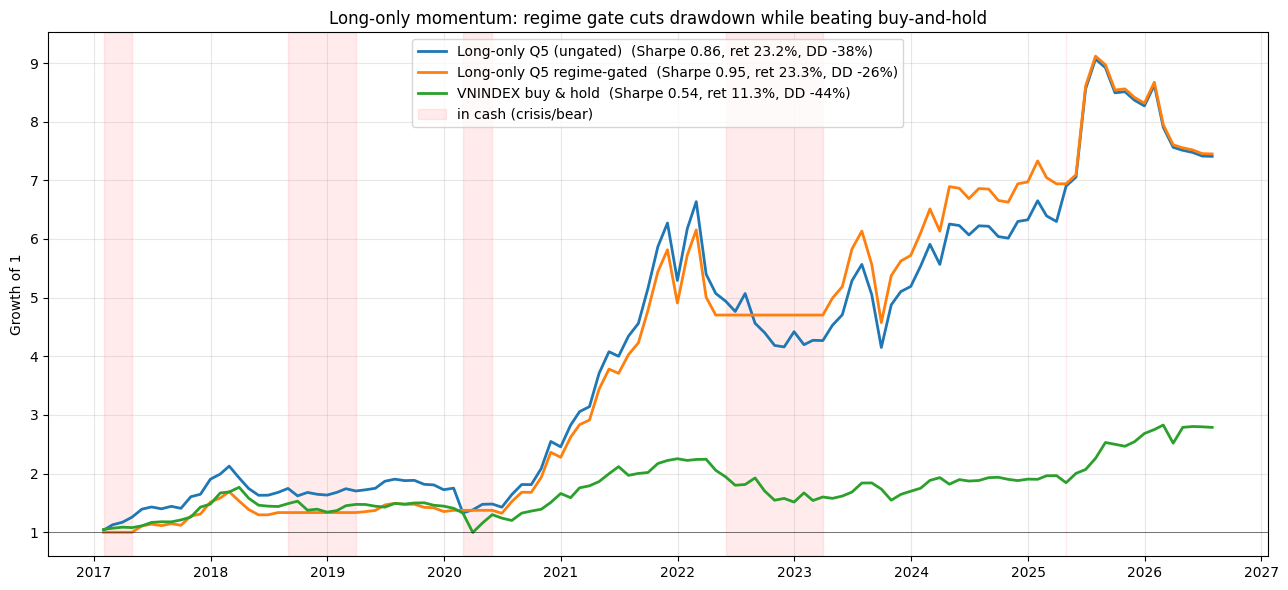

In [69]:
# ── Regime-gated LONG-ONLY backtest vs ungated & vs buy-and-hold VNINDEX ─────
FAVORABLE = {'CALM BULL', 'TRENDING BULL', 'CHOPPY / RANGE', 'CRASH RECOVERY'}   # cash in crisis/bear

W_win = build_weights(mom_win, long_short=False, weighting='invvol')   # LONG-ONLY top quintile
net_win, _, _ = backtest(W_win, fwd_win)
gate      = reg_static.reindex(net_win.index).isin(FAVORABLE)     # swap to reg_wf for the leak-free version
net_gated = net_win.where(gate, 0.0)                              # 0 return = sitting in cash
bench_g   = close[BENCHMARK].resample('ME').last().pct_change().reindex(net_win.index)

comp = {'Long-only Q5 (ungated)': net_win, 'Long-only Q5 regime-gated': net_gated,
        f'{BENCHMARK} buy & hold': bench_g}
res_g = {k: perf(v) for k, v in comp.items()}
tbl = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk != 'eq'} for k, v in res_g.items()}).T
print(f'Regime-gated LONG-ONLY backtest (in cash {int((~gate).sum())}/{len(gate)} months, in crisis/bear):')
display(tbl[['ann_ret', 'ann_vol', 'sharpe', 'max_dd']].round(3))

plt.figure(figsize=(13, 6))
for name, v in res_g.items():
    plt.plot(v['eq'].index, v['eq'].values, lw=2, label=f"{name}  (Sharpe {v['sharpe']:.2f}, "
             f"ret {v['ann_ret']:.1%}, DD {v['max_dd']:.0%})")
flat = ~gate
plt.fill_between(net_win.index, 0, 1, where=flat.values, transform=plt.gca().get_xaxis_transform(),
                 color='red', alpha=0.08, label='in cash (crisis/bear)')
plt.axhline(1, color='k', lw=0.7, alpha=0.5)
plt.title('Long-only momentum: regime gate cuts drawdown while beating buy-and-hold')
plt.ylabel('Growth of 1'); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Verdict & next steps

**As a market-neutral long-short bet, momentum is inconclusive here — but the long-only,
regime-gated version is a genuinely useful strategy.**
- **Step 2 IC** — default 12&#8209;1 mean IC ≈ +0.005, **t ≈ 0.2**: indistinguishable from zero.
- **Step 6 sweep** — *no* lookback/skip/universe combo reaches **|t| > 2**; the best (6&#8209;month,
  no skip) only hits t ≈ 1.4 — and that is the max over 24 correlated tests, so the honest bar is
  higher still.
- **Step 6b** — the no-skip edge is **real, not a same-close artifact**: it survives a +1-day
  execution gap (t 1.41 → 1.51). `skip = 0` beats `skip = 1` because this market shows short-horizon
  *continuation*, the opposite of the US reversal effect the skip is meant to dodge.
- **Steps 7–8 — go long-only.** The short book was the drag (shorting a rising market costs money);
  dropping it flips the picture. **Long-only top-quintile** returns **≈ +24%/yr, Sharpe ≈ 0.88**,
  versus **VNINDEX ≈ +11%/yr, Sharpe ≈ 0.54** — momentum handily beats buy-and-hold. Adding the
  **regime gate** (cash in crisis/bear) keeps the return and cuts max drawdown from **≈ −38% → ≈ −26%**
  (Sharpe ≈ 0.95). *Caveat:* the gate uses full-sample `regime_static` labels (look-ahead) as a
  diagnostic — a live strategy must use the walk-forward `regime_wf` labels.

**How to trade it (Step 7 book).** Hold the top-quintile winners, inverse-vol sized, fully invested,
and **go to cash when the regime turns crisis/bear**. This is a long-only momentum + market-timing
overlay — the regime gate is the biggest lever, not the individual stock picks.

**Reading order** — IC (2) → quantiles (3) → Pearson risk (4) → backtest (5) → sweep (6) →
execution-lag stress test (6b) → current long-only book (7) → regime gate (8).

**Where to look next**
- **Make the gate tradable.** Re-run Step 8 with `reg_wf` and confirm the drawdown/Sharpe benefit
  survives leak-free labeling; volatility-target the book.
- **Neutralize.** Trade the residual of momentum regressed on sector / size / the reversal factor.
- **Different factor.** Point this same IC/quantile/backtest harness at short-term reversal or
  low-volatility as the primary signal.
- **Cleaner universe.** Point-in-time (survivorship-free) membership and a daily-marked,
  calendar-overlapping backtest would tighten every estimate above.